---
# Grover's Search Algorithm
---

이 노트북에서는 Grover's Search Algorithm을 구현하는 실습을 진행할 것입니다. Basic Quantum operator의 리뷰부터 시작해서, 특정한 양자 상태를 입력, 증폭시키는 코드를 구현하고, 이를 응용한 문제들을 해결해보도록 하겠습니다.

---
Basic operators Review
---
$H=\frac{1}{2}\begin{bmatrix}
1&1\\1&-1
\end{bmatrix}$: Hadamard Gate; 

$\begin{matrix}
|0\rangle\rightarrow|+\rangle
&|+\rangle\rightarrow|0\rangle
\\|1\rangle\rightarrow|-\rangle
&|-\rangle\rightarrow|1\rangle
\end{matrix}$

$X=\begin{bmatrix}
0&1\\1&0
\end{bmatrix}$: BitFlip Gate(X gate, Not Gate); 

$\begin{matrix}
|0\rangle\rightarrow|1\rangle
\\|1\rangle\rightarrow|0\rangle
\end{matrix}$

$Z=\begin{bmatrix}
1&0\\0&-1
\end{bmatrix}$: PhaseFlip Gate(Z gate); 

$\begin{matrix}
|0\rangle\rightarrow|0\rangle
\\|1\rangle\rightarrow-|1\rangle
\end{matrix}$

$CX=\begin{bmatrix}
1&0&0&0\\
0&1&0&0\\
0&0&0&1\\
0&0&1&0
\end{bmatrix}$: Controlled Not Gate(Controlled X Gate); 

$\begin{matrix}
|00\rangle\rightarrow|00\rangle&
|01\rangle\rightarrow|01\rangle\\
|10\rangle\rightarrow|11\rangle&
|11\rangle\rightarrow|10\rangle
\end{matrix}$

$CCX$: Toffoli gate(MCX, MCT)


$\begin{matrix}
|000\rangle\rightarrow|000\rangle&
|001\rangle\rightarrow|001\rangle\\
|010\rangle\rightarrow|010\rangle&
|011\rangle\rightarrow|011\rangle\\
|100\rangle\rightarrow|100\rangle&
|101\rangle\rightarrow|101\rangle\\
|110\rangle\rightarrow|111\rangle&
|111\rangle\rightarrow|110\rangle
\end{matrix}$

---
$HXH=Z$
---
$ZHZ=X$
---



# 균등한 중첩상태 만들기
Grover's Search Algorithm의 핵심적인 개념 중 하나는, 양자컴퓨터가 함수가 탐색할 수 있는 '모든' 경우의 수를 동시에 탐색한다는 것입니다.
이를 실제로 구현하기 위해, 탐색가능한 모든 상태를 균등하게 탐색하는 부분부터 다시 구현하겠습니다.

In [130]:
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram
import numpy as np

#직접 타겟 변수를 설정하세요.

target = '01'
n_qubits = 2



In [131]:
#####################
##코드를 작성해주세요
def initial(n_qubits):
    qc=QuantumCircuit(n_qubits)
    for j in range(n_qubits):
        qc.h(j)
    return qc

###############
circuit=QuantumCircuit(n_qubits)
circuit.append(initial(n_qubits),[0,1])
circuit.decompose().draw(fold=0)

┌───┐
q_0: ┤ H ├
     ├───┤
q_1: ┤ H ├
     └───┘

<br> 

# Quantum Oracle 정의
이제, Grover's Search Algorithm을 적용하기 위해, Quantum Oracle을 정의하고, 적용하겠습니다.
Quantum Oracle의 역할은 traget 함수의 정보를 입력하고, 중첩된 상태를 target 상태에 대해 reflection시켜주는 역할을 합니다.
우리는 목표로 하는 target 함수를 안다고 가정하고 예제를 진행하겠습니다.

$$U_\omega \,\, = \,\, I - 2|\omega\rangle\langle \omega| \,\, = \, \, U^\dagger( I-2|\vec{0}\rangle\langle\vec{0}|) U $$

$|\omega\rangle$: target bitstring.

$|\vec{0}\rangle$: All zero state.

$U$:Unitary $|\vec{0}\rangle \rightarrow|\omega\rangle$ 


In [132]:
##############
##Add Code Here
def oracle(n_qubits,target):
    qc=QuantumCircuit(n_qubits)
    for x, b in enumerate(target[::-1]):
        if (b=='1'):
            qc.x(x)#Implementing Target function information
    qc.x(n_qubits-1)
    qc.barrier()
    qc.h(n_qubits-1)
    qc.mcx(list(range(n_qubits-1)),n_qubits-1,ctrl_state=f"{0:0{n_qubits-1}b}")
    qc.h(n_qubits-1)
    qc.barrier()
    qc.x(n_qubits-1)
    for x, b in enumerate(target[::-1]):
        if (b=='1'):
            qc.x(x)
    return qc

##############
circuit=QuantumCircuit(n_qubits)
circuit.append(oracle(n_qubits,target),[0,1])
circuit.decompose().draw(fold=0)

┌───┐ ░                 ░ ┌───┐
q_0: ┤ X ├─░────────o────────░─┤ X ├
     ├───┤ ░ ┌───┐┌─┴─┐┌───┐ ░ ├───┤
q_1: ┤ X ├─░─┤ H ├┤ X ├┤ H ├─░─┤ X ├
     └───┘ ░ └───┘└───┘└───┘ ░ └───┘

# Diffusion Operator 정의
Diffusion Operator를 정의하겠습니다. Diffusion Operator는 다음과 같이 정의됩니다.
$$ U_s = I - 2|\vec{s}\rangle \langle\vec{s}| $$



In [133]:


##############
##Add Code Here
def diffusion(n_qubits):
    qc=QuantumCircuit(n_qubits)
    for j in range(n_qubits):
        qc.h(j)

    qc.x(n_qubits-1)
    qc.barrier()
    qc.h(n_qubits-1)
    qc.mcx(list(range(n_qubits-1)),n_qubits-1,ctrl_state=f"{0:0{n_qubits-1}b}")
    qc.h(n_qubits-1)
    qc.barrier()
    qc.x(n_qubits-1)
    for j in range(n_qubits):
        qc.h(j)
    return qc
##############
circuit=QuantumCircuit(n_qubits)
circuit.append(diffusion(n_qubits),[0,1])
circuit.decompose().draw(fold=0)

┌───┐      ░                 ░ ┌───┐     
q_0: ┤ H ├──────░────────o────────░─┤ H ├─────
     ├───┤┌───┐ ░ ┌───┐┌─┴─┐┌───┐ ░ ├───┤┌───┐
q_1: ┤ H ├┤ X ├─░─┤ H ├┤ X ├┤ H ├─░─┤ X ├┤ H ├
     └───┘└───┘ ░ └───┘└───┘└───┘ ░ └───┘└───┘

# Compose the entire quantum Circuit

이제, 작성한 양자회로들을 결합하겠습니다.


In [134]:
# Define the circuit object
qc=QuantumCircuit(n_qubits)
##############
##Add Code Here
qc.append(initial(n_qubits),range(n_qubits))
qc.append(oracle(n_qubits,target),range(n_qubits))
qc.append(diffusion(n_qubits),range(n_qubits))
##############
qc.measure_all()
qc.decompose().draw()



┌───┐┌───┐ ░                 ░ ┌───┐┌───┐      ░                 ░ »
   q_0: ┤ H ├┤ X ├─░────────o────────░─┤ X ├┤ H ├──────░────────o────────░─»
        ├───┤├───┤ ░ ┌───┐┌─┴─┐┌───┐ ░ ├───┤├───┤┌───┐ ░ ┌───┐┌─┴─┐┌───┐ ░ »
   q_1: ┤ H ├┤ X ├─░─┤ H ├┤ X ├┤ H ├─░─┤ X ├┤ H ├┤ X ├─░─┤ H ├┤ X ├┤ H ├─░─»
        └───┘└───┘ ░ └───┘└───┘└───┘ ░ └───┘└───┘└───┘ ░ └───┘└───┘└───┘ ░ »
meas: 2/═══════════════════════════════════════════════════════════════════»
                                                                           »
«        ┌───┐      ░ ┌─┐   
«   q_0: ┤ H ├──────░─┤M├───
«        ├───┤┌───┐ ░ └╥┘┌─┐
«   q_1: ┤ X ├┤ H ├─░──╫─┤M├
«        └───┘└───┘ ░  ║ └╥┘
«meas: 2/══════════════╩══╩═
«                      0  1

Result(backend_name='aer_simulator', backend_version='0.17.2', job_id='3839e207-d9e3-46ff-9c24-21ec420a099b', success=True, results=[ExperimentResult(shots=100000, success=True, meas_level=2, data=ExperimentResultData(counts={'0x1': 100000}), header={'creg_sizes': [['meas', 2]], 'global_phase': 0.0, 'memory_slots': 2, 'n_qubits': 2, 'name': 'circuit-254', 'qreg_sizes': [['q', 2]], 'metadata': {}}, status=DONE, seed_simulator=986351318, metadata={'batched_shots_optimization': False, 'required_memory_mb': 0, 'method': 'stabilizer', 'active_input_qubits': [0, 1], 'device': 'CPU', 'remapped_qubits': False, 'num_qubits': 2, 'num_clbits': 2, 'time_taken': 0.2959621, 'sample_measure_time': 0.0386615, 'input_qubit_map': [[0, 0], [1, 1]], 'max_memory_mb': 32452, 'measure_sampling': True, 'noise': 'ideal', 'parallel_shots': 1, 'parallel_state_update': 20, 'runtime_parameter_bind': False, 'num_bind_params': 1, 'fusion': {'enabled': False}}, time_taken=0.2959621)], date=2025-10-30T14:27:19.334719,

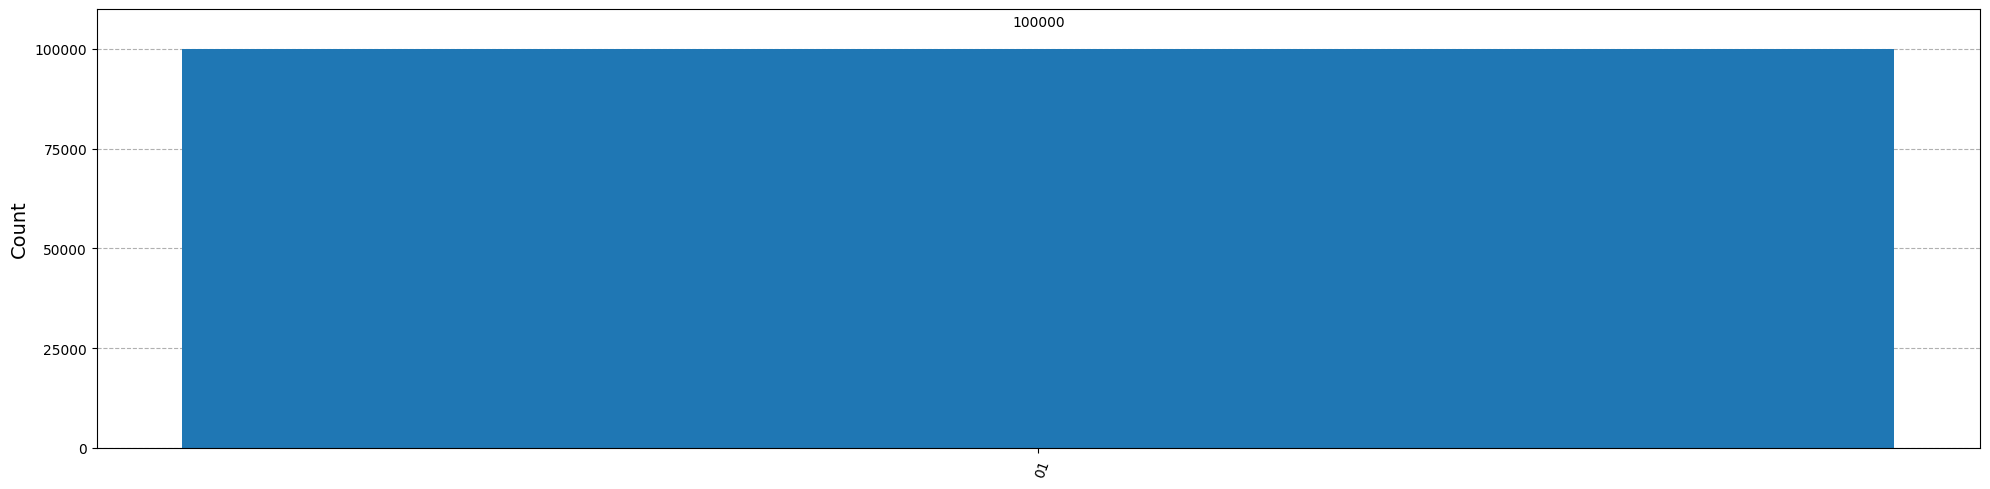

In [135]:
from qiskit import transpile
backend = AerSimulator()
n_shots = 100000 # Number of measurements

# Run the circuit over n_shots times
tqc=transpile(qc,
              backend=backend,
              optimization_level=0
              )
result = backend.run(tqc, shots=n_shots).result()
print(result)
counts = result.get_counts()
# Output state
display(plot_histogram(counts,figsize=(20,5)))

# Grover Iteration 횟수에 따른 분포 변화

In [ ]:

w_counts = []
one_counts = []
n_qubits=10
target='1000000000'
# Define the circuit object


####################
##Add Code Here
#Define the Oracles


for iterations in range(80):

    qc = QuantumCircuit(n_qubits)
    qc.append(initial(n_qubits),range(n_qubits))
    for j in range(iterations):
        qc.append(oracle(n_qubits,target),range(n_qubits))
        qc.append(diffusion(n_qubits),range(n_qubits))
    qc.measure_all()

        
    tqc=transpile(qc,
              backend=backend,
              optimization_level=3
              )
    
    n_shots = 10000 # Number of measurements
    
    # Run the circuit over n_shots times
    result = backend.run(tqc, shots=n_shots).result()
    counts = result.get_counts()
    
    
    #w_counts.append(counts[bits]/n_shots)
    w_counts.append(counts.get(target, 0))


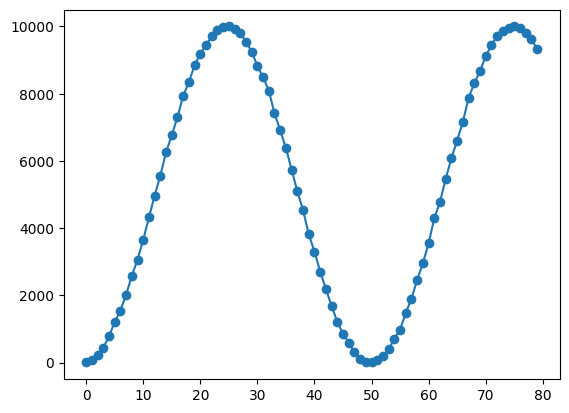

In [172]:
from matplotlib import pyplot as plt
plt.plot(w_counts, marker = 'o')

<br> 

# Ex.2) Binary Sudoku(이진 스도쿠)
이번 예제에서는 Grover Algorithm의 응용으로, 이진 스도쿠 문제를 풀어보겠습니다.
직접 target의 정보를 입력한 이전 문제와 다르게, 이번에는 target의 정보를 모르는 상태로 target의 조건만을 알고있기에, 해당 조건을 양자컴퓨터에 입력하는 과정부터 하겠습니다.

In [ ]:
def XOR(qc,a,b,output):
    qc.cx(a,output)
    qc.cx(b,output)

In [ ]:
from qiskit import QuantumRegister, ClassicalRegister
in_qubit =QuantumRegister(2,name='input')
out_qubit=QuantumRegister(1,name='output')
qc=QuantumCircuit(in_qubit,out_qubit)
XOR(qc,in_qubit[0],in_qubit[1],out_qubit)
qc.draw()

input_0: ──■───────
           │       
input_1: ──┼────■──
         ┌─┴─┐┌─┴─┐
 output: ┤ X ├┤ X ├
         └───┘└───┘

In [ ]:
var_qubits=QuantumRegister(4,name='v')
clause_qubits=QuantumRegister(4,name='c')
output_qubit=QuantumRegister(1,name='out')
clause_list=[[0,1],[0,2],[1,3],[2,3]]#스도쿠 조건 함수


qc=QuantumCircuit(var_qubits,clause_qubits,output_qubit)

j=0
for clause in clause_list:
    XOR(qc,clause[0],clause[1],clause_qubits[j])
    j+=1

qc.draw()

v_0: ──■─────────■───────────────────────────
       │         │                           
v_1: ──┼────■────┼─────────■─────────────────
       │    │    │         │                 
v_2: ──┼────┼────┼────■────┼─────────■───────
       │    │    │    │    │         │       
v_3: ──┼────┼────┼────┼────┼────■────┼────■──
     ┌─┴─┐┌─┴─┐  │    │    │    │    │    │  
c_0: ┤ X ├┤ X ├──┼────┼────┼────┼────┼────┼──
     └───┘└───┘┌─┴─┐┌─┴─┐  │    │    │    │  
c_1: ──────────┤ X ├┤ X ├──┼────┼────┼────┼──
               └───┘└───┘┌─┴─┐┌─┴─┐  │    │  
c_2: ────────────────────┤ X ├┤ X ├──┼────┼──
                         └───┘└───┘┌─┴─┐┌─┴─┐
c_3: ──────────────────────────────┤ X ├┤ X ├
                                   └───┘└───┘
out: ────────────────────────────────────────

In [ ]:
qc.mcx(clause_qubits,output_qubit[0])
qc.draw()

v_0: ──■─────────■────────────────────────────────
       │         │                                
v_1: ──┼────■────┼─────────■──────────────────────
       │    │    │         │                      
v_2: ──┼────┼────┼────■────┼─────────■────────────
       │    │    │    │    │         │            
v_3: ──┼────┼────┼────┼────┼────■────┼────■───────
     ┌─┴─┐┌─┴─┐  │    │    │    │    │    │       
c_0: ┤ X ├┤ X ├──┼────┼────┼────┼────┼────┼────■──
     └───┘└───┘┌─┴─┐┌─┴─┐  │    │    │    │    │  
c_1: ──────────┤ X ├┤ X ├──┼────┼────┼────┼────■──
               └───┘└───┘┌─┴─┐┌─┴─┐  │    │    │  
c_2: ────────────────────┤ X ├┤ X ├──┼────┼────■──
                         └───┘└───┘┌─┴─┐┌─┴─┐  │  
c_3: ──────────────────────────────┤ X ├┤ X ├──■──
                                   └───┘└───┘┌─┴─┐
out: ────────────────────────────────────────┤ X ├
                                             └───┘

In [202]:
from qiskit import QuantumRegister, ClassicalRegister
var_qubits=QuantumRegister(4,name='v')
clause_qubits=QuantumRegister(4,name='c')
output_qubit=QuantumRegister(4,name='o')
cbits=ClassicalRegister(4,name='cbits')
sudoku_op=QuantumCircuit(var_qubits,clause_qubits,output_qubit,cbits)

def sudoku_oracle(sudoku_op, clause_list,clause_qubits):
    j=0
    for clause in clause_list:
        XOR(sudoku_op,clause[0],clause[1],clause_qubits[j])
        j+=1

    sudoku_op.mcx(clause_qubits,output_qubit[0])
    
    j=0
    for clause in clause_list:
        XOR(sudoku_op,clause[0],clause[1],clause_qubits[j])
        j+=1

sudoku_oracle(sudoku_op,clause_list,clause_qubits)
sudoku_op.draw()

»
    v_0: ──■─────────■──────────────────────────────────■─────────■────────────»
           │         │                                  │         │            »
    v_1: ──┼────■────┼─────────■────────────────────────┼────■────┼─────────■──»
           │    │    │         │                        │    │    │         │  »
    v_2: ──┼────┼────┼────■────┼─────────■──────────────┼────┼────┼────■────┼──»
           │    │    │    │    │         │              │    │    │    │    │  »
    v_3: ──┼────┼────┼────┼────┼────■────┼────■─────────┼────┼────┼────┼────┼──»
         ┌─┴─┐┌─┴─┐  │    │    │    │    │    │       ┌─┴─┐┌─┴─┐  │    │    │  »
    c_0: ┤ X ├┤ X ├──┼────┼────┼────┼────┼────┼────■──┤ X ├┤ X ├──┼────┼────┼──»
         └───┘└───┘┌─┴─┐┌─┴─┐  │    │    │    │    │  └───┘└───┘┌─┴─┐┌─┴─┐  │  »
    c_1: ──────────┤ X ├┤ X ├──┼────┼────┼────┼────■────────────┤ X ├┤ X ├──┼──»
                   └───┘└───┘┌─┴─┐┌─┴─┐  │    │    │            └───┘└───┘┌─┴─┐»
    c_2: ────────────────────┤ X ├┤ X ├──┼────┼────■──────────────────────┤ X ├»
                             └───┘└───┘┌─┴─┐┌─┴─┐  │                      └───┘»
    c_3: ──────────────────────────────┤ X ├┤ X ├──■───────────────────────────»
                                       └───┘└───┘┌─┴─┐                         »
    o_0: ────────────────────────────────────────┤ X ├─────────────────────────»
                                                 └───┘                         »
    o_1: ──────────────────────────────────────────────────────────────────────»
                                                                               »
    o_2: ──────────────────────────────────────────────────────────────────────»
                                                                               »
    o_3: ──────────────────────────────────────────────────────────────────────»
                                                                               »
cbits: 4/══════════════════════════════════════════════════════════════════════»
                                                                               »
«                        
«    v_0: ───────────────
«                        
«    v_1: ───────────────
«                        
«    v_2: ───────■───────
«                │       
«    v_3: ──■────┼────■──
«           │    │    │  
«    c_0: ──┼────┼────┼──
«           │    │    │  
«    c_1: ──┼────┼────┼──
«         ┌─┴─┐  │    │  
«    c_2: ┤ X ├──┼────┼──
«         └───┘┌─┴─┐┌─┴─┐
«    c_3: ─────┤ X ├┤ X ├
«              └───┘└───┘
«    o_0: ───────────────
«                        
«    o_1: ───────────────
«                        
«    o_2: ───────────────
«                        
«    o_3: ───────────────
«                        
«cbits: 4/═══════════════
«

In [195]:
qc=QuantumCircuit(var_qubits,clause_qubits,output_qubit,cbits)
qc.append(initial(4),range(4))
for j in list(range(2)):
    sudoku_oracle(qc,clause_list,clause_qubits)
    qc.append(diffusion(4),[0,1,2,3])
qc.measure(var_qubits,cbits)
qc.draw(fold=-1)

┌────────────────┐                                                                                     ┌────────────────┐                                                                                     ┌────────────────┐┌─┐         
    v_0: ┤0               ├──■─────────■──────────────────────────────────■─────────■───────────────────────────┤0               ├──■─────────■──────────────────────────────────■─────────■───────────────────────────┤0               ├┤M├─────────
         │                │  │         │                                  │         │                           │                │  │         │                                  │         │                           │                │└╥┘┌─┐      
    v_1: ┤1               ├──┼────■────┼─────────■────────────────────────┼────■────┼─────────■─────────────────┤1               ├──┼────■────┼─────────■────────────────────────┼────■────┼─────────■─────────────────┤1               ├─╫─┤M├──────
         │  circuit-83961 │  │    │    │         │                        │    │    │         │                 │  circuit-83964 │  │    │    │         │                        │    │    │         │                 │  circuit-83967 │ ║ └╥┘┌─┐   
    v_2: ┤2               ├──┼────┼────┼────■────┼─────────■──────────────┼────┼────┼────■────┼─────────■───────┤2               ├──┼────┼────┼────■────┼─────────■──────────────┼────┼────┼────■────┼─────────■───────┤2               ├─╫──╫─┤M├───
         │                │  │    │    │    │    │         │              │    │    │    │    │         │       │                │  │    │    │    │    │         │              │    │    │    │    │         │       │                │ ║  ║ └╥┘┌─┐
    v_3: ┤3               ├──┼────┼────┼────┼────┼────■────┼────■─────────┼────┼────┼────┼────┼────■────┼────■──┤3               ├──┼────┼────┼────┼────┼────■────┼────■─────────┼────┼────┼────┼────┼────■────┼────■──┤3               ├─╫──╫──╫─┤M├
         └────────────────┘┌─┴─┐┌─┴─┐  │    │    │    │    │    │       ┌─┴─┐┌─┴─┐  │    │    │    │    │    │  └────────────────┘┌─┴─┐┌─┴─┐  │    │    │    │    │    │       ┌─┴─┐┌─┴─┐  │    │    │    │    │    │  └────────────────┘ ║  ║  ║ └╥┘
    c_0: ──────────────────┤ X ├┤ X ├──┼────┼────┼────┼────┼────┼────■──┤ X ├┤ X ├──┼────┼────┼────┼────┼────┼────────────────────┤ X ├┤ X ├──┼────┼────┼────┼────┼────┼────■──┤ X ├┤ X ├──┼────┼────┼────┼────┼────┼─────────────────────╫──╫──╫──╫─
                           └───┘└───┘┌─┴─┐┌─┴─┐  │    │    │    │    │  └───┘└───┘┌─┴─┐┌─┴─┐  │    │    │    │                    └───┘└───┘┌─┴─┐┌─┴─┐  │    │    │    │    │  └───┘└───┘┌─┴─┐┌─┴─┐  │    │    │    │                     ║  ║  ║  ║ 
    c_1: ────────────────────────────┤ X ├┤ X ├──┼────┼────┼────┼────■────────────┤ X ├┤ X ├──┼────┼────┼────┼──────────────────────────────┤ X ├┤ X ├──┼────┼────┼────┼────■────────────┤ X ├┤ X ├──┼────┼────┼────┼─────────────────────╫──╫──╫──╫─
                                     └───┘└───┘┌─┴─┐┌─┴─┐  │    │    │            └───┘└───┘┌─┴─┐┌─┴─┐  │    │                              └───┘└───┘┌─┴─┐┌─┴─┐  │    │    │            └───┘└───┘┌─┴─┐┌─┴─┐  │    │                     ║  ║  ║  ║ 
    c_2: ──────────────────────────────────────┤ X ├┤ X ├──┼────┼────■──────────────────────┤ X ├┤ X ├──┼────┼────────────────────────────────────────┤ X ├┤ X ├──┼────┼────■──────────────────────┤ X ├┤ X ├──┼────┼─────────────────────╫──╫──╫──╫─
                                               └───┘└───┘┌─┴─┐┌─┴─┐  │                      └───┘└───┘┌─┴─┐┌─┴─┐                                      └───┘└───┘┌─┴─┐┌─┴─┐  │                      └───┘└───┘┌─┴─┐┌─┴─┐                   ║  ║  ║  ║ 
    c_3: ────────────────────────────────────────────────┤ X ├┤ X ├──■────────────────────────────────┤ X ├┤ X ├────────────────────────────────────────────────┤ X ├┤ X ├──■────────────────────────────────┤ X ├┤ X ├───────────────────╫──╫──╫──╫─
                                                         └───┘└───┘┌─┴─┐ 

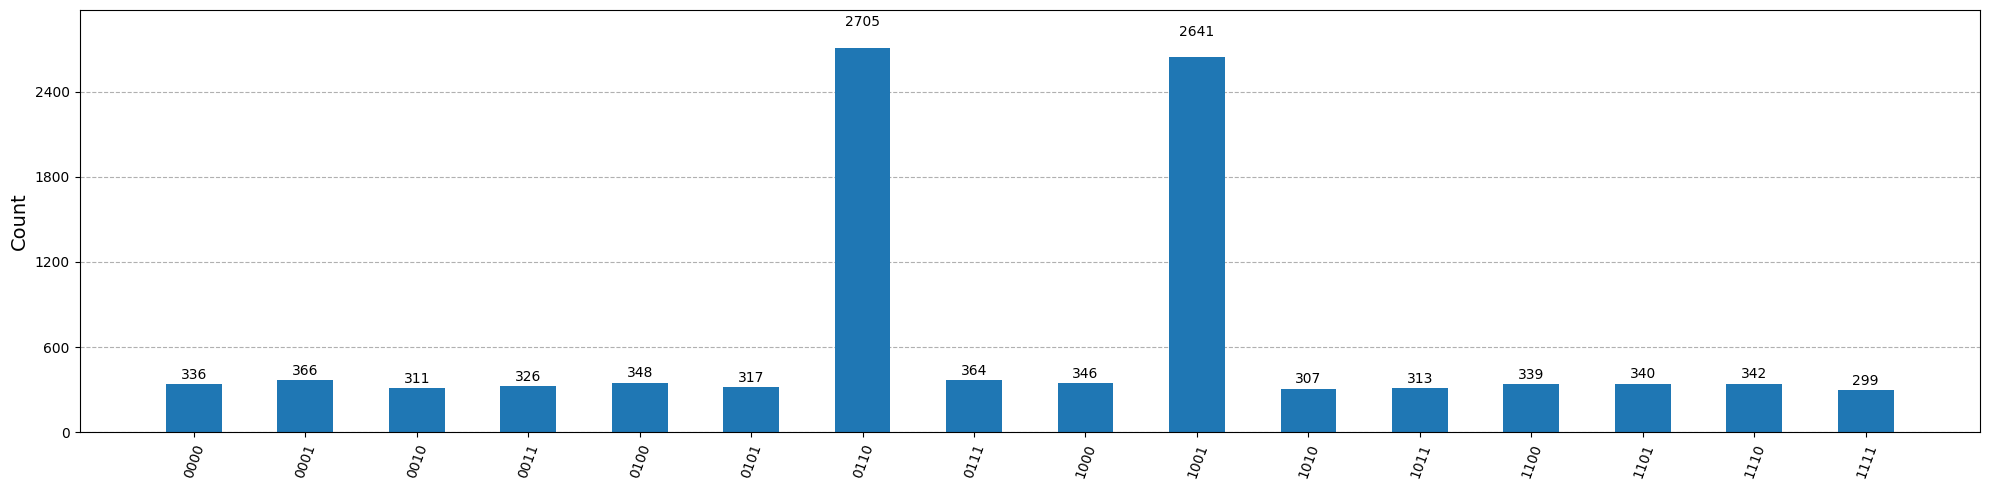

In [196]:
tqc=transpile(qc,
          backend=backend,
          optimization_level=3
          )
n_shots = 10000 # Number of measurements

# Run the circuit over n_shots times
result = backend.run(tqc, shots=n_shots).result()
counts = result.get_counts()
# Output state
display(plot_histogram(counts,figsize=(20,5)))